#Tarefa 6 Python Ciências dos Alimentos

Carolina Ferreira Onias (16859769)

Luciana Miki Sumi (16885456)

Melissa Rebechi Santana (17015126)

#Fontes
A base de dados escolhida foi a "Efeito do processamento UAT (Ultra Alta Temperatura) sobre características físico-químicas do leite. Nessa base, são analisadas diversas características físico-químicas de leites que passaram por tratamentos diferentes. Decidimos relacionar a acidez (média) e o pH (médio) do leite UAT (ou UHT), do leite cru e do leite pasteurizado. Ambas as variáveis são quantitativas contínuas. O pH, potencial de hidrogênio, indica a quantidade de íons de hidrogênio (H+) livres de uma solução (nesse caso, o leite), geralmente medida pelo pHmetro, que mostra o resultado dentro de uma escala de 0 a 14. Quanto mais próxima do 0, mais ácida é a solução, portanto, quanto mais perto do 14, mais alcalina é a solução. O meio termo (perto do 7) são soluções neutras.
 Já a acidez é medida em graus Dornic (°D), que é a quantidade de hidróxido de sódio em 0,1mL (em solução, mas sempre bem alcalina) necessária para neutralizar 10mL do leite. O principal ácido do leite é o ácido lático, e essa relação de graus dornic e acidez pode indicar se houve alguma adulteração ou mesmo contaminação durante o processamento do leite.

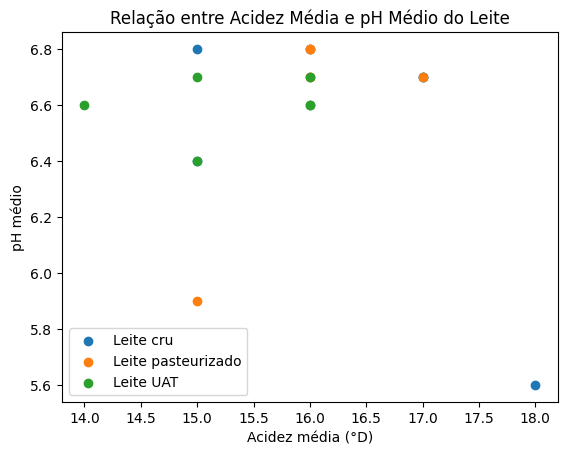

In [13]:
import matplotlib.pyplot as plt

# Dados de acidez (°D)
acidez_cru = [18, 15, 17, 15, 17, 16]
acidez_pasteurizado = [15, 16, 17, 16, 16, 16]
acidez_uat = [15, 14, 15, 16, 16, 16]

# Dados de pH
ph_cru = [5.6, 6.4, 6.7, 6.8, 6.7, 6.8]
ph_pasteurizado = [5.9, 6.8, 6.7, 6.7, 6.7, 6.8]
ph_uat = [6.4, 6.6, 6.7, 6.7, 6.6, 6.6]

# Gráfico de dispersão
plt.scatter(acidez_cru, ph_cru, label="Leite cru")
plt.scatter(acidez_pasteurizado, ph_pasteurizado, label="Leite pasteurizado")
plt.scatter(acidez_uat, ph_uat, label="Leite UAT")

# Nome dos eixos
plt.xlabel("Acidez média (°D)")
plt.ylabel("pH médio")

# Título
plt.title("Relação entre Acidez Média e pH Médio do Leite")

# Legenda
plt.legend()

# Mostrar o gráfico
plt.show()

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [17]:
acidez_cru = [18, 15, 17, 15, 17, 16]
ph_cru = [5.6, 6.4, 6.7, 6.8, 6.7, 6.8]

acidez_pasteurizado = [15, 16, 17, 16, 16, 16]
ph_pasteurizado = [5.9, 6.8, 6.7, 6.7, 6.7, 6.8]

acidez_uat = [15, 14, 15, 16, 16, 16]
ph_uat = [6.4, 6.6, 6.7, 6.7, 6.6, 6.6]

In [18]:
resultado_cru = linregress(acidez_cru, ph_cru)

print("Leite cru")
print("Coeficiente de correlação:", resultado_cru.rvalue)
print("R²:", resultado_cru.rvalue**2)

Leite cru
Coeficiente de correlação: -0.5685352436149612
R²: 0.3232323232323233


In [19]:
resultado_cru.rvalue**2

np.float64(0.3232323232323233)

In [20]:
resultado_cru.slope

np.float64(-0.2181818181818182)

In [21]:
resultado_cru.intercept

np.float64(10.063636363636363)

In [23]:
x_cru = [min(acidez_cru), max(acidez_cru)]

y_cru = [ resultado_cru.intercept + resultado_cru.slope * x
    for x in x_cru]

In [24]:
resultado_pasteurizado = linregress(
    acidez_pasteurizado,
    ph_pasteurizado
)

resultado_uat = linregress(
    acidez_uat,
    ph_uat
)

In [25]:
x_pasteurizado = [
    min(acidez_pasteurizado),
    max(acidez_pasteurizado)
]

y_pasteurizado = [
    resultado_pasteurizado.intercept +
    resultado_pasteurizado.slope * x
    for x in x_pasteurizado
]

In [26]:
x_uat = [
    min(acidez_uat),
    max(acidez_uat)
]

y_uat = [
    resultado_uat.intercept +
    resultado_uat.slope * x
    for x in x_uat
]

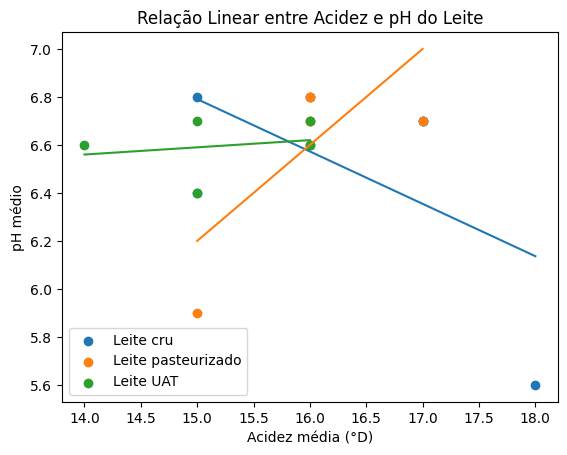

In [27]:
#Gráfico
plt.scatter(acidez_cru, ph_cru, label="Leite cru")
plt.plot(x_cru, y_cru)

plt.scatter(
    acidez_pasteurizado,
    ph_pasteurizado,
    label="Leite pasteurizado"
)
plt.plot(x_pasteurizado, y_pasteurizado)

plt.scatter(acidez_uat, ph_uat, label="Leite UAT")
plt.plot(x_uat, y_uat)

plt.xlabel("Acidez média (°D)")
plt.ylabel("pH médio")

plt.title("Relação Linear entre Acidez e pH do Leite")

plt.legend()

plt.show()

O gráfico de dispersão foi criado a partir da correlação linear de Pearson (r), que é um coeficiente que mede a força da relação de variáveis quantitativas em forma de linha, variando de -1 a 1. Isso não significa que uma variável é a causa da outra nem uma inclinação, mas sim o que é esperado acontecer com base nos dados (tipo, o que é esperado de Y quando X é tal valor) em comparação ao dado real obtido. Ou seja, é um compartilhamento de variância e linearidade obtido por uma fórmula. Muitos autores defendem que existem intervalos para determinar se é uma correlação fraca, média ou forte. Durante a progrmação, já foi calculado os coeficientes r de cada tipo de leite.


In [28]:
#Cálculo de correlação linear de Pearson (r)
import pandas as pd
import numpy as np
from scipy import stats

data_cru = {
    'Acidez': [18, 15, 17, 15, 17, 16],
    'pH': [5.6, 6.4, 6.7, 6.8, 6.7, 6.8]
}

data_past = {
    'Acidez': [15, 16, 17, 16, 16, 16],
    'pH': [5.9, 6.8, 6.7, 6.7, 6.7, 6.8]
}

data_uat = {
    'Acidez': [15, 14, 15, 16, 16, 16],
    'pH': [6.4, 6.6, 6.7, 6.7, 6.6, 6.6]
}

def calc_pearson(df, name):
    x = df['Acidez']
    y = df['pH']
    r, p = stats.pearsonr(x, y)
    r2 = r**2
    print(f"--- {name} ---")
    print(f"r = {r:.3f}, R2 = {r2:.3f}, p = {p:.3f}")

    # Step by step components:
    x_mean = x.mean()
    y_mean = y.mean()
    dx = x - x_mean
    dy = y - y_mean
    dx_dy = dx * dy
    dx2 = dx**2
    dy2 = dy**2

    table_step = pd.DataFrame({
        'Acidez (X)': x,
        'pH (Y)': y,
        'X - X_bar': dx,
        'Y - Y_bar': dy,
        '(X - X_bar)*(Y - Y_bar)': dx_dy,
        '(X - X_bar)^2': dx2,
        '(Y - Y_bar)^2': dy2
    })
    print(table_step)
    print(f"Soma (X-X_bar)*(Y-Y_bar): {dx_dy.sum():.4f}")
    print(f"Soma (X-X_bar)^2: {dx2.sum():.4f}")
    print(f"Soma (Y-Y_bar)^2: {dy2.sum():.4f}")
    print()

calc_pearson(pd.DataFrame(data_cru), "Cru")
calc_pearson(pd.DataFrame(data_past), "Pasteurizado")
calc_pearson(pd.DataFrame(data_uat), "UAT")

--- Cru ---
r = -0.569, R2 = 0.323, p = 0.239
   Acidez (X)  pH (Y)  X - X_bar  Y - Y_bar  (X - X_bar)*(Y - Y_bar)  \
0          18     5.6   1.666667       -0.9                -1.500000   
1          15     6.4  -1.333333       -0.1                 0.133333   
2          17     6.7   0.666667        0.2                 0.133333   
3          15     6.8  -1.333333        0.3                -0.400000   
4          17     6.7   0.666667        0.2                 0.133333   
5          16     6.8  -0.333333        0.3                -0.100000   

   (X - X_bar)^2  (Y - Y_bar)^2  
0       2.777778           0.81  
1       1.777778           0.01  
2       0.444444           0.04  
3       1.777778           0.09  
4       0.444444           0.04  
5       0.111111           0.09  
Soma (X-X_bar)*(Y-Y_bar): -1.6000
Soma (X-X_bar)^2: 7.3333
Soma (Y-Y_bar)^2: 1.0800

--- Pasteurizado ---
r = 0.730, R2 = 0.533, p = 0.099
   Acidez (X)  pH (Y)  X - X_bar  Y - Y_bar  (X - X_bar)*(Y - Y_bar)  \


#r do leite cru
O resultado obtido foi de r = -0,569. Por ser um resultado negativo e mais próximo ao -1, seria classificado como uma relação moderada entre acidez e pH do leite cru, onde, quando um aumenta, o outro diminui, o que é um resultado esperado, pois quanto maior a quantidade de ácido lático presente, menor será o pH.

#r do leite pasteurizado
O r = 0,730 indica que há uma relação forte e positiva, ou seja, quanto maior o pH, maior a acidez. Isso não é muito condizente com a realidade, então esse resultado foi conduzido a não ter sentido por ser uma pequena quantidade de amostras (apenas 6), sendo que uma delas tinha um valor de pH muito abaixo (5,9) do comum (entre 6,5 e 7, até mesmo ao observar o restante das amostras), ou seja, essa amostra fora do comum foi um outlier que puxou o resultado final para fora do esperado.

#r do leite UAT (UHT)
Por fim, o r = 0,224 é positivo porém fraco, então a relação linear de acidez X pH do leite UHT é praticamente irrelevante, pois não há previsibilidade entre as variações.

#r igual ou próximo a 0 significa o que?
Se a correlação linear de Pearson for próxima ou igual a 0, como foi o caso do leite UAT, significa que, como o nome indica, não há previsibilidade >linear<. Porém, poderia haver outro tipo de relação, por exemplo, uma relação curvilínea, como uma parábola. Ter o resultado parecido com zero não quer dizer que acidez e pH não tiveram nenhuma relação no leite UAT, apenas que não tiveram variâncias e linearidade esperadas. Esse tipo de leite é o que mais passou por tratamento térmico, o que pode ser um fator a se considerar no r fraco, porém positivo. O objetivo do leite UHT é ser o mais "resistente" possível, então ele é o que menos deve ter variação de acidez e de pH, então se houvesse uma linearidade, a variação teria que ser a mínima possível, quase que constante, causando um "Bug" na formula de r, que se baseia totalmente nessas diferenças entre os valores.

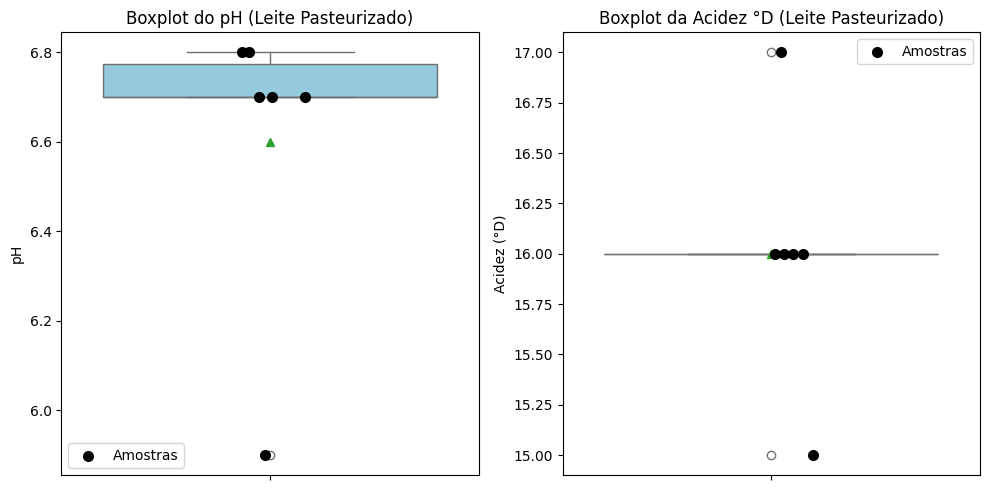

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Criar o DataFrame com os dados do Leite Pasteurizado
dados_pasteurizado = {
    'Colheita': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Acidez': [15, 16, 17, 16, 16, 16],
    'pH': [5.9, 6.8, 6.7, 6.7, 6.7, 6.8],
}

df = pd.DataFrame(dados_pasteurizado)

# 2. Configurar a figura com 2 subplots (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 3. Gerar o Boxplot do pH (onde está o outlier 5.9)
sns.boxplot(y=df['pH'], ax=axes[0], color='skyblue', showmeans=True)
sns.stripplot(
    y=df['pH'],
    ax=axes[0],
    color='black',
    size=8,
    jitter=True,
    label='Amostras',
)
axes[0].set_title('Boxplot do pH (Leite Pasteurizado)')
axes[0].set_ylabel('pH')

# 4. Gerar o Boxplot da Acidez
sns.boxplot(y=df['Acidez'], ax=axes[1], color='lightgreen', showmeans=True)
sns.stripplot(
    y=df['Acidez'],
    ax=axes[1],
    color='black',
    size=8,
    jitter=True,
    label='Amostras',
)
axes[1].set_title('Boxplot da Acidez °D (Leite Pasteurizado)')
axes[1].set_ylabel('Acidez (°D)')

# 5. Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [30]:
#Markdown
from IPython.display import Markdown

# String formatada em Markdown com suporte a LaTeX para as fórmulas
formulas_markdown = """
### Fórmulas de Correlação e Regressão Linear Simples

**1. Coeficiente de Correlação de Pearson ($r$)**

$$r = \\frac{\\sum_{i=1}^{n} (X_i - \\bar{X})(Y_i - \\bar{Y})}{\\sqrt{\\sum_{i=1}^{n} (X_i - \\bar{X})^2 \\cdot \\sum_{i=1}^{n} (Y_i - \\bar{Y})^2}}$$

*Onde $\\bar{X}$ e $\\bar{Y}$ representam as médias amostrais das variáveis.*

---

**2. Regressão Linear Simples**

Equação da reta de regressão:
$$\\hat{Y} = \\beta_0 + \\beta_1 X$$

* **Inclinação (Coeficiente Angular - $\\beta_1$):**
$$\\beta_1 = \\frac{\\sum_{i=1}^{n} (X_i - \\bar{X})(Y_i - \\bar{Y})}{\\sum_{i=1}^{n} (X_i - \\bar{X})^2} = r \\cdot \\frac{s_y}{s_x}$$

* **Intercepto (Coeficiente Linear - $\\beta_0$):**
$$\\beta_0 = \\bar{Y} - \\beta_1 \\bar{X}$$

*Onde $s_x$ e $s_y$ são os desvios-padrão de $X$ e $Y$, respectivamente.*
"""

# Exibe o conteúdo formatado no Notebook
display(Markdown(formulas_markdown))


### Fórmulas de Correlação e Regressão Linear Simples

**1. Coeficiente de Correlação de Pearson ($r$)**

$$r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2 \cdot \sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$$

*Onde $\bar{X}$ e $\bar{Y}$ representam as médias amostrais das variáveis.*

---

**2. Regressão Linear Simples**

Equação da reta de regressão:
$$\hat{Y} = \beta_0 + \beta_1 X$$

* **Inclinação (Coeficiente Angular - $\beta_1$):**
$$\beta_1 = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2} = r \cdot \frac{s_y}{s_x}$$

* **Intercepto (Coeficiente Linear - $\beta_0$):**
$$\beta_0 = \bar{Y} - \beta_1 \bar{X}$$

*Onde $s_x$ e $s_y$ são os desvios-padrão de $X$ e $Y$, respectivamente.*


#Conclusão
Após a interpretação dos dados obtidos, conclui-se que a relação linear entre acidez e pH variam conforme o grau de processamento térmico do leite. Isso ficou explícito pois o resultado de linearidade esperado ocorreu apenas no leite cru, o único que não passa por nenhum tipo de processamento térmico. No leite pasteurizado, a relação foi distorcida devido a presença do outlier, e no leite UAT, a relação foi quase nula devido sua estabilização térmica para maior tempo de prateleira.
Esses resultados só foram alcançados com o auxílio da correlação linear de pearson e regressão linear, pois ajudam a ter um maior controle de qualidedade, maior padronização, praticidade industrial e principalemente detectar fraudes a anomalias nos leites.